In [2]:
!pip install control
!pip install -U scikit-fuzzy

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
from sklearn.neural_network import MLPRegressor
from scipy.signal import tf2ss

In [4]:
# -----------------------------
# Função de Transferência de Planta de Terceira Ordem
# -----------------------------

K=1.0
tau1=1.0
tau2=0.5
tau3=0.2

num_p = [K]
den_p = np.convolve([tau1, 1], np.convolve([tau2, 1], [tau3, 1]))


def get_plant_tf(num_p, den_p, K, tau1, tau2, tau3):
    """
    G(s) = K / ((tau1*s + 1)*(tau2*s + 1)*(tau3*s + 1))
    """
    return ctrl.TransferFunction(num_p, den_p)

# -----------------------------
# Transferência do Sensor
# -----------------------------

tau_s=0.1

num_s = [1]
den_s = [tau_s, 1]

def get_sensor_tf(num_s, den_s, tau_s):
    """
    H(s) = 1 / (tau_s*s + 1)
    """
    return ctrl.TransferFunction(num_s, den_s)

# -----------------------------
# Controlador PID em Laplace
# -----------------------------
def get_pid_tf(Kp, Ki, Kd):
    """
    PID(s) = Kp + Ki/s + Kd*s = (Kd*s^2 + Kp*s + Ki) / s
    """
    num = [Kd, Kp, Ki]
    den = [1, 0]
    return ctrl.TransferFunction(num, den)

# -----------------------------
# Planta e Sensor em Espaço de Estados
# -----------------------------

A_p, B_p, C_p, D_p = tf2ss(num_p, den_p)
A_s, B_s, C_s, D_s = tf2ss(num_s, den_s)

In [5]:
# ----------------------------------------
# 2. GA-based PID Optimization
# ----------------------------------------
def fitness(Kp, Ki, Kd,
            setpoint=1.0,
            time=np.arange(0, 20, 0.02),
            overshoot_weight=20.0):
    plant = get_plant_tf(num_p, den_p, K, tau1, tau2, tau3)
    sensor = get_sensor_tf(num_s, den_s, tau_s)
    controller = get_pid_tf(Kp, Ki, Kd)
    loop = controller * plant * sensor
    closed_loop = ctrl.feedback(loop, 1)

    # Resposta ao degrau
    t, y = ctrl.step_response(closed_loop, T=time)

    # Erro absoluto acumulado
    error = setpoint - y
    dt = t[1] - t[0]
    total_error = np.sum(np.abs(error)) * dt

    # Cálculo do sobressinal
    overshoot = np.max(y) - setpoint
    overshoot = max(0.0, overshoot)

    # Fitness penaliza sobressinal
    fitness_val = 1.0 / (1.0 + total_error + overshoot_weight * overshoot)
    return fitness_val

# -----------------------------
# Operadores do Algoritmo Genético
# -----------------------------
def init_population(size):
    pop = []
    for _ in range(size):
        pop.append({
            'Kp': random.uniform(0, 10),
            'Ki': random.uniform(0, 10),
            'Kd': random.uniform(0, 10)
        })
    return pop


def select_parents(pop):
    fits = [fitness(ind['Kp'], ind['Ki'], ind['Kd']) for ind in pop]
    total = sum(fits)
    probs = [f / total for f in fits]
    parents = np.random.choice(pop, size=2, p=probs, replace=False)
    return parents[0], parents[1]


def crossover(p1, p2):
    child = {}
    for k in p1:
        child[k] = p1[k] if random.random() < 0.5 else p2[k]
    return child


def mutate(ind, rate=0.1, scale=1.0):
    for k in ind:
        if random.random() < rate:
            ind[k] += random.uniform(-scale, scale)
            ind[k] = max(0, ind[k])
    return ind

# -----------------------------
# Algoritmo Genético
# -----------------------------
def genetic_algorithm(generations=20, pop_size=50):
    pop = init_population(pop_size)
    best = None
    best_fit = -np.inf

    for gen in range(generations):
        new_pop = []
        for _ in range(pop_size // 2):
            p1, p2 = select_parents(pop)
            c1 = mutate(crossover(p1, p2))
            c2 = mutate(crossover(p1, p2))
            new_pop.extend([c1, c2])
        pop = new_pop

        for ind in pop:
            fit = fitness(ind['Kp'], ind['Ki'], ind['Kd'])
            if fit > best_fit:
                best_fit = fit
                best = ind.copy()
        print(f"Geração {gen+1}: Melhor fitness = {best_fit:.4f}")

    return best

# -----------------------------
# Execução e Plotagem Final
# -----------------------------
best_params = genetic_algorithm()
print("Parâmetros ótimos:", best_params)

t = np.arange(0, 20, 0.01)
plant = get_plant_tf(num_p, den_p, K, tau1, tau2, tau3)
sensor = get_sensor_tf(num_s, den_s, tau_s)
pid = get_pid_tf(**best_params)
loop = pid * plant * sensor
closed_loop = ctrl.feedback(loop, 1)
t_ga, y_ga = ctrl.step_response(closed_loop, T=t)

Geração 1: Melhor fitness = 0.5398
Geração 2: Melhor fitness = 0.5474
Geração 3: Melhor fitness = 0.5474
Geração 4: Melhor fitness = 0.5474
Geração 5: Melhor fitness = 0.5474
Geração 6: Melhor fitness = 0.5474
Geração 7: Melhor fitness = 0.5474
Geração 8: Melhor fitness = 0.5474
Geração 9: Melhor fitness = 0.5474
Geração 10: Melhor fitness = 0.5474
Geração 11: Melhor fitness = 0.5474
Geração 12: Melhor fitness = 0.5474
Geração 13: Melhor fitness = 0.5727
Geração 14: Melhor fitness = 0.5727
Geração 15: Melhor fitness = 0.6353
Geração 16: Melhor fitness = 0.6353
Geração 17: Melhor fitness = 0.6353
Geração 18: Melhor fitness = 0.6353
Geração 19: Melhor fitness = 0.6353
Geração 20: Melhor fitness = 0.6353
Parâmetros ótimos: {'Kp': 3.397224024144611, 'Ki': 1.843012377539772, 'Kd': 1.8635146114328216}


In [6]:
# ----------------------------------------
# 3. Fuzzy-PID Controller
# ----------------------------------------

# 2) Funções de pertinência fuzzy
def mu_neg(x):
    return 1.0 if x <= -1 else (-x if x < 0 else 0.0)

def mu_zero(x):
  if abs(x) >= 0.5: return 0.0
  return 1 - 2*abs(x)

def mu_pos(x):
    return 0.0 if x <= 0 else (x if x < 1 else 1.0)

# 3) Centróides para Kp, Ki, Kd
centroids_Kp = {'low': 2.0, 'medium': 3.0, 'high': 5.0}
centroids_Ki = {'low': 1.0, 'medium': 1.0, 'high': 2.0}
centroids_Kd = {'low': 0.1, 'medium': 0.5, 'high': 1.0}

# 4) Regras fuzzy
rules = [
    ('pos','pos',  'medium','low','high'),
    ('pos','zero', 'medium','low','high'),
    ('pos','neg',  'low',   'low','medium'),
    ('zero','pos','medium','low','high'),
    ('zero','zero','medium','high','medium'),
    ('zero','neg','low','high','low'),
    ('neg','pos','low','low','medium'),
    ('neg','zero','low','medium','low'),
    ('neg','neg','medium','medium','low'),
]

# 5) Parâmetros de simulação
dt = 0.01
t = np.arange(0, 20.0, dt)
n_steps = len(t)

# 6) Inicialização de estados
x_p = np.zeros(A_p.shape[0])
x_s = np.zeros(A_s.shape[0])
sensor_out = 0.0
integral = 0.0
prev_error = 0.0
SP = 1.0

# 7) Histórico
y_fuzzy = np.zeros(n_steps)
sensor_hist = np.zeros(n_steps)

# 8) Loop de simulação
for i in range(n_steps):
    error = SP - sensor_out
    delta_error = error - prev_error
    prev_error = error

    # Normalização [-1,1]
    e_n  = np.clip(error, -1, 1)
    de_n = np.clip(delta_error, -1, 1)
    mu_e  = {'neg': mu_neg(e_n),  'zero': mu_zero(e_n),  'pos': mu_pos(e_n)}
    mu_de = {'neg': mu_neg(de_n), 'zero': mu_zero(de_n), 'pos': mu_pos(de_n)}

    # Inferência fuzzy e defuzzificação
    num_Kp = num_Ki = num_Kd = den = 0.0
    for et, det, kp_t, ki_t, kd_t in rules:
        w = min(mu_e[et], mu_de[det])
        num_Kp += w * centroids_Kp[kp_t]
        num_Ki += w * centroids_Ki[ki_t]
        num_Kd += w * centroids_Kd[kd_t]
        den += w
    Kp = num_Kp/den if den else 0.0
    Ki = num_Ki/den if den else 0.0
    Kd = num_Kd/den if den else 0.0

    # PID
    integral += error * dt
    derivative = delta_error / dt if dt else 0.0
    u = Kp*error + Ki*integral + Kd*derivative

    # Atualização da planta (SS + Euler)
    x_p += (A_p @ x_p + B_p.flatten()*u) * dt
    y = (C_p @ x_p + D_p.flatten()*u).item()

    # Atualização do sensor (SS + Euler)
    x_s += (A_s @ x_s + B_s.flatten()*y) * dt
    sensor_out = (C_s @ x_s + D_s.flatten()*y).item()

    # Armazena saída
    y_fuzzy[i] = y
    sensor_hist[i] = sensor_out

In [7]:
# ----------------------------------------
# 4. NN-based Controller (trained on GA-PID data)
# ----------------------------------------
# Ziegler-Nichols
Ku, Pu = 5.0, 4.0
Kp_ZN = 0.6 * Ku
Ki_ZN = 2 * Kp_ZN / Pu
Kd_ZN = Kp_ZN * Pu / 8

# Gerar dados de treinamento (diferentes amplitudes de degrau)
sp_list = np.linspace(0.5, 2.0, 10)
X_train = np.column_stack([sp_list, np.zeros_like(sp_list)])  # [SP, y_prev=0]
y_train = np.tile([Kp_ZN, Ki_ZN, Kd_ZN], (len(sp_list), 1))

# Treinar RNA (MLP)
nn = MLPRegressor(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
nn.fit(X_train, y_train)

# Parâmetros da simulação
dt = 0.01
t_final = 20.0
time = np.arange(0, t_final, dt)
n = len(time)

# Inicializar estados para NN
x_f = np.zeros(A_p.shape[0]); x_s_f = np.zeros(A_s.shape[0])
x_n = np.zeros(A_p.shape[0]); x_s_n = np.zeros(A_s.shape[0])
prev_err_f = prev_err_n = 0.0
int_f = int_n = 0.0
y_prev_n = 0.0

# Armazenar saídas
y_nn = np.zeros(n)
s_nn = np.zeros(n)

# Loop de simulação
for i in range(n):
    # RNA-PID
    err_n = 1.0 - s_nn[i-1] if i>0 else 1.0
    de_n = err_n - prev_err_n; prev_err_n = err_n
    inp = np.array([[1.0, y_prev_n]])
    Kp_n, Ki_n, Kd_n = nn.predict(inp)[0]
    int_n += err_n*dt; der_n = de_n/dt if dt else 0
    u_n = Kp_n*err_n + Ki_n*int_n + Kd_n*der_n
    x_n += (A_p@x_n + B_p.flatten()*u_n)*dt
    y_n = (C_p@x_n + D_p.flatten()*u_n).item()
    x_s_n += (A_s@x_s_n + B_s.flatten()*y_n)*dt
    s_n = (C_s@x_s_n + D_s.flatten()*y_n).item()

    y_nn[i] = y_n; s_nn[i] = s_n; y_prev_n = y_n

# Plot
#plt.figure(figsize=(10,5))
#plt.plot(time, s_nn,   label='Sensor RNA-PID', linestyle='--')
#plt.plot(time, np.ones_like(time), ':', label='Setpoint')
#plt.xlabel('Tempo [s]'); plt.ylabel('Amplitude')
#plt.title('RNA-PID')
#plt.legend(); plt.grid(True); plt.tight_layout()
#plt.show()

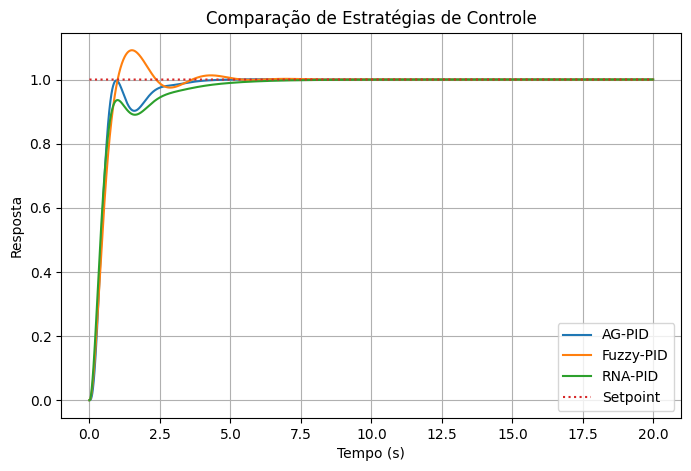

In [8]:
# ----------------------------------------
# 5. Plot and Compare
# ----------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(t, y_ga, label='AG-PID')
plt.plot(t, y_fuzzy, label='Fuzzy-PID')
plt.plot(t, y_nn, label='RNA-PID')
plt.plot(t, SP * np.ones_like(t), ':', label='Setpoint')
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta')
plt.title('Comparação de Estratégias de Controle')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
import numpy as np
import pandas as pd
from IPython.display import display

# Função para calcular métricas de desempenho
def compute_metrics(y, t, ref=1.0, tol=0.02):
    mse = np.mean((y - ref)**2)
    overshoot = np.max(y) - ref
    # Determina o tempo de acomodação (entrando e permanecendo dentro da banda de tolerância)
    within_tol = np.abs(y - ref) <= tol * ref
    settling_time = np.nan
    for i in range(len(t)):
        if np.all(within_tol[i:]):
            settling_time = t[i]
            break
    return mse, overshoot, settling_time

# Supondo que y_ga, y_fuzzy, y_nn e t já estejam definidos no escopo
metrics = []
for name, y in [('GA-PID', y_ga), ('Fuzzy-PID', y_fuzzy), ('RNA-PID', y_nn)]:
    mse, overshoot, settling = compute_metrics(y, t)
    metrics.append({
        'Modelo': name,
        'MSE': mse,
        'Overshoot': overshoot,
        'Tempo de Acomodação (s)': settling
    })

df_metrics = pd.DataFrame(metrics)
display(df_metrics)


,Modelo,MSE,Overshoot,Tempo de Acomodação (s)
0,GA-PID,0.016776483204024997,0.0008324402166053346,2.74
1,Fuzzy-PID,0.017098,0.091408,3.15
2,RNA-PID,0.015505,-0.0,4.05
